**Problema:**

https://www.kaggle.com/competitions/rossmann-store-sales

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

/Users/manuel/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/manuel/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
data_stores = pd.read_csv("./Rossmann/store.csv", index_col="Store")
data_stores

,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Store,,,,,,,,,
1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [4]:
data_stores.value_counts("StoreType")

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

In [5]:
data_stores.value_counts("Assortment")

Assortment
a    593
c    513
b      9
Name: count, dtype: int64

In [11]:
data_todas_tiendas = pd.read_csv("./Rossmann/train.csv", parse_dates=["Date"])
data_todas_tiendas

/var/folders/6p/5s4g02lx4g7b6wlgkrj91l_40000gn/T/ipykernel_79259/1671087955.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  data_todas_tiendas = pd.read_csv("./Rossmann/train.csv", parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931
...,...,...,...,...,...,...,...,...,...,...
1001594,1111,2,2013-01-01,0,0,0,0,a,1,225066
1001595,1112,2,2013-01-01,0,0,0,0,a,1,775592
1001596,1113,2,2013-01-01,0,0,0,0,a,1,135205
1001597,1114,2,2013-01-01,0,0,0,0,a,1,954751


In [51]:
store = 1

data = data_todas_tiendas[data_todas_tiendas["Store"]==store].drop("Id", axis=1).sort_values("Date")
data[:10]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1000485,1,2,2013-01-01,0,0,0,0,a,1
999370,1,3,2013-01-02,5530,668,1,0,0,1
998255,1,4,2013-01-03,4327,578,1,0,0,1
997140,1,5,2013-01-04,4486,619,1,0,0,1
996025,1,6,2013-01-05,4997,635,1,0,0,1
994910,1,7,2013-01-06,0,0,0,0,0,1
993795,1,1,2013-01-07,7176,785,1,1,0,1
992680,1,2,2013-01-08,5580,654,1,1,0,1
991565,1,3,2013-01-09,5471,626,1,1,0,1
990450,1,4,2013-01-10,4892,615,1,1,0,1


In [52]:
data.drop("Store", axis=1, inplace=True)
data

,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1000485,2,2013-01-01,0,0,0,0,a,1
999370,3,2013-01-02,5530,668,1,0,0,1
998255,4,2013-01-03,4327,578,1,0,0,1
997140,5,2013-01-04,4486,619,1,0,0,1
996025,6,2013-01-05,4997,635,1,0,0,1
...,...,...,...,...,...,...,...,...
4460,1,2015-07-13,5054,553,1,1,0,0
3345,2,2015-07-14,5042,544,1,1,0,0
2230,3,2015-07-15,4767,550,1,1,0,0
1115,4,2015-07-16,4427,517,1,1,0,0


In [53]:
!cal 1 2013

     Enero 2013       
do lu ma mi ju vi sá  
       1  2  3  4  5  
 6  7  8  9 10 11 12  
13 14 15 16 17 18 19  
20 21 22 23 24 25 26  
27 28 29 30 31        
                      


In [54]:
data.dtypes

DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

In [55]:
np.unique(data["Date"][1:].values - data["Date"][:-1].values)

array([86400000000], dtype='timedelta64[us]')

In [56]:
86400000000 / 1e6 / 60 / 60 / 24

1.0

In [57]:
px.line(data_frame=data, x="Date", y=["Sales", "Customers"])

In [58]:
data.corr(numeric_only=True)

,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
DayOfWeek,1.000000,-0.500584,-0.494103,-0.543158,-0.393238,-0.062546
Sales,-0.500584,1.000000,0.984457,0.889231,0.469716,-0.001119
Customers,-0.494103,0.984457,1.000000,0.927731,0.376747,-0.006127
Open,-0.543158,0.889231,0.927731,1.000000,0.299066,-0.005612
Promo,-0.393238,0.469716,0.376747,0.299066,1.000000,0.011485
SchoolHoliday,-0.062546,-0.001119,-0.006127,-0.005612,0.011485,1.000000


In [59]:
data.drop("Customers", axis=1, inplace=True)
data

,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday
1000485,2,2013-01-01,0,0,0,a,1
999370,3,2013-01-02,5530,1,0,0,1
998255,4,2013-01-03,4327,1,0,0,1
997140,5,2013-01-04,4486,1,0,0,1
996025,6,2013-01-05,4997,1,0,0,1
...,...,...,...,...,...,...,...
4460,1,2015-07-13,5054,1,1,0,0
3345,2,2015-07-14,5042,1,1,0,0
2230,3,2015-07-15,4767,1,1,0,0
1115,4,2015-07-16,4427,1,1,0,0


In [60]:
data["StateHoliday"].unique()

array(['a', '0', 0, 'b', 'c'], dtype=object)

In [61]:
data.loc[data["StateHoliday"]==0, "StateHoliday"] = '0'

In [62]:
data["StateHoliday"].unique()

array(['a', '0', 'b', 'c'], dtype=object)

In [64]:
data["SchoolHoliday"].unique()

array([1, 0])

In [67]:
data["festivo"] = 1*((data["SchoolHoliday"]==1) | (data["StateHoliday"]!='0'))

In [68]:
data

,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,festivo
1000485,2,2013-01-01,0,0,0,a,1,1
999370,3,2013-01-02,5530,1,0,0,1,1
998255,4,2013-01-03,4327,1,0,0,1,1
997140,5,2013-01-04,4486,1,0,0,1,1
996025,6,2013-01-05,4997,1,0,0,1,1
...,...,...,...,...,...,...,...,...
4460,1,2015-07-13,5054,1,1,0,0,0
3345,2,2015-07-14,5042,1,1,0,0,0
2230,3,2015-07-15,4767,1,1,0,0,0
1115,4,2015-07-16,4427,1,1,0,0,0


In [77]:
meses = [x.month for x in data["Date"]]
data["mes"] = meses
data

,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,festivo,mes
1000485,2,2013-01-01,0,0,0,a,1,1,1
999370,3,2013-01-02,5530,1,0,0,1,1,1
998255,4,2013-01-03,4327,1,0,0,1,1,1
997140,5,2013-01-04,4486,1,0,0,1,1,1
996025,6,2013-01-05,4997,1,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...
4460,1,2015-07-13,5054,1,1,0,0,0,7
3345,2,2015-07-14,5042,1,1,0,0,0,7
2230,3,2015-07-15,4767,1,1,0,0,0,7
1115,4,2015-07-16,4427,1,1,0,0,0,7


In [125]:
fechas = data["Date"].values
target = data["Sales"].values
mes    = data["mes"].values
festivo = data["festivo"].values
day_of_week = data["DayOfWeek"].values

promo = data["Promo"].values
open_ = data["Open"].values

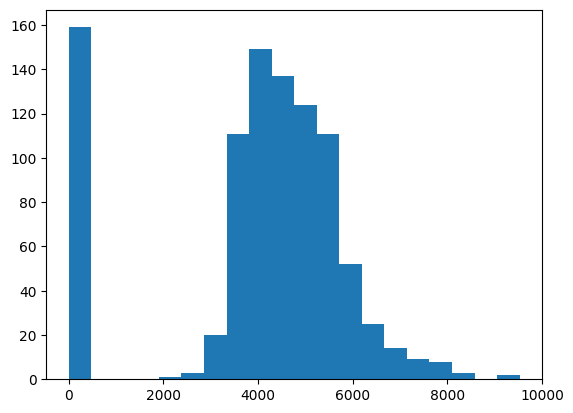

In [79]:
plt.hist(target, bins=20);

### Modelo "dummy" (persistente)

Es un modelo que predice para mañana lo mismo que hoy

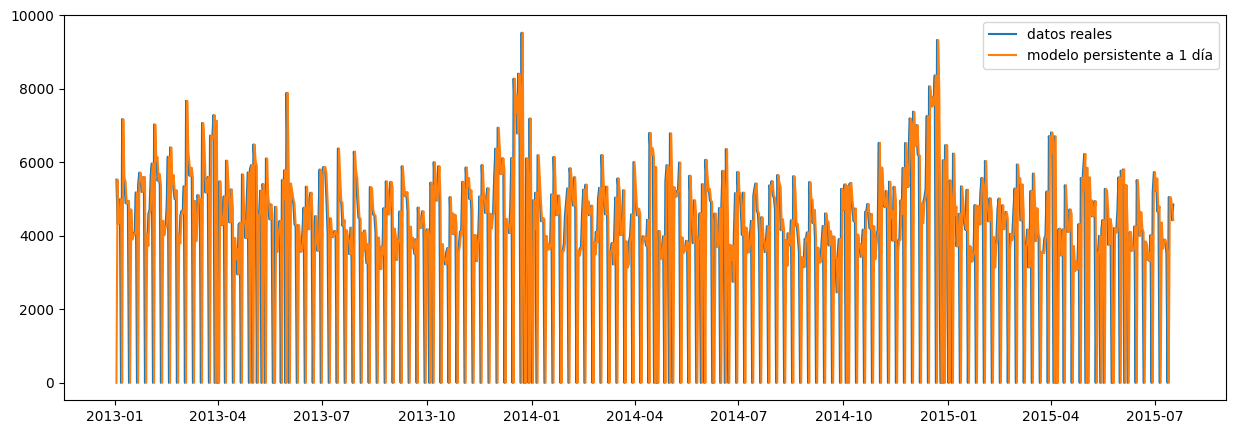

In [80]:
fechas_comparacion = fechas[1:]
target_comparacion = target[1:]
pred_persistente   = target[0:-1]

plt.figure(figsize=(15,5))
plt.plot(fechas_comparacion, target_comparacion, label="datos reales")
plt.plot(fechas_comparacion, pred_persistente, label="modelo persistente a 1 día")
#plt.xlim([fechas_comparacion[0], fechas_comparacion[30]])
plt.legend();

In [81]:
from sklearn.metrics import r2_score as R2_score # coeficiente de determinación

In [82]:
R2_score(target_comparacion, pred_persistente)

-1.2577293520039978

In [83]:
R2_scores_persistente = []
for desplazamiento in range(0,4*7+1):
    fechas_comparacion = fechas[desplazamiento:]
    target_comparacion = target[desplazamiento:]
    pred_persistente   = target[0:(len(target)-desplazamiento)]
    R2_score_persistente = R2_score(target_comparacion, pred_persistente)
    print("R2 del modelo persistente a {} días:".format(desplazamiento), R2_score_persistente)
    R2_scores_persistente.append(R2_score_persistente)

R2 del modelo persistente a 0 días: 1.0
R2 del modelo persistente a 1 días: -1.2577293520039978
R2 del modelo persistente a 2 días: -1.075003559659459
R2 del modelo persistente a 3 días: -0.874019723756712
R2 del modelo persistente a 4 días: -1.0065183509052211
R2 del modelo persistente a 5 días: -1.2216721364660268
R2 del modelo persistente a 6 días: -1.4632098670390166
R2 del modelo persistente a 7 días: 0.2558937155551685
R2 del modelo persistente a 8 días: -1.4930646655532165
R2 del modelo persistente a 9 días: -1.3095870208041487
R2 del modelo persistente a 10 días: -0.9952501782763825
R2 del modelo persistente a 11 días: -0.9864768200584959
R2 del modelo persistente a 12 días: -1.165311549697265
R2 del modelo persistente a 13 días: -1.3025113614008093
R2 del modelo persistente a 14 días: 0.4422521706968081
R2 del modelo persistente a 15 días: -1.317277480431815
R2 del modelo persistente a 16 días: -1.1215228453713175
R2 del modelo persistente a 17 días: -0.9450980001815819
R2 del

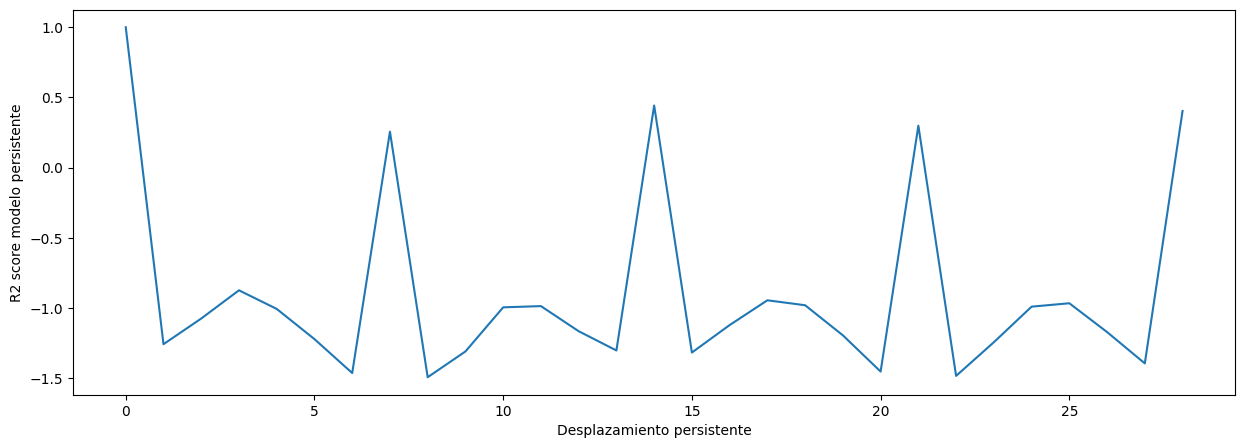

In [84]:
plt.figure(figsize=(15,5))
plt.plot(R2_scores_persistente)
plt.xlabel("Desplazamiento persistente")
plt.ylabel("R2 score modelo persistente");

### Conclusión:

- Hay una estacionalidad muy clara (ciclos) cada 7/14 días
- Mi modelo predictivo debería batir claramente el R2 score de 0.44 (modelo persistente de 14 días)

## Modelo con red recurrente

In [ ]:
# Funciones auxiliares:

# Transformación de escala (ajustar el factor en función del problema)
def transform(x):
    return x/5000

def inverse_transform(x_escalado):
    return x_escalado*5000

from matplotlib.ticker import MaxNLocator

def grafica_entrenamiento(tr_mse, val_mse):
    ax=plt.figure(figsize=(10,4)).gca()
    plt.plot(1+np.arange(len(tr_mse)), tr_mse) #np.arange(3) → [0, 1, 2]
    plt.plot(1+np.arange(len(val_mse)), val_mse) #np.arange(3) → [0, 1, 2]
    plt.title('mse del modelo', fontsize=18)
    plt.xlabel('epoca', fontsize=18)
    plt.ylabel('mse', fontsize=18)
    plt.legend(['entrenamiento', 'validación'], loc='upper left')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()

In [86]:
target_transf = transform(target)
target_transf

array([0.    , 1.106 , 0.8654, 0.8972, 0.9994, 0.    , 1.4352, 1.116 ,
       1.0942, 0.9784, 0.9762, 0.9904, 0.    , 0.9434, 0.78  , 0.8016,
       0.8088, 0.8254, 1.0364, 0.    , 1.0788, 1.144 , 1.1156, 1.039 ,
       1.1172, 1.1196, 0.    , 0.811 , 0.745 , 0.9202, 0.9418, 1.1266,
       1.194 , 0.    , 1.4064, 1.2098, 1.228 , 1.0998, 1.1362, 1.074 ,
       0.    , 0.8818, 0.803 , 0.8504, 0.8482, 0.9618, 1.2308, 0.    ,
       1.2814, 1.0772, 1.132 , 1.0522, 1.    , 1.0474, 0.    , 0.8076,
       0.7588, 0.9116, 0.9352, 0.9222, 1.07  , 0.    , 1.535 , 1.26  ,
       1.1946, 1.1274, 1.1706, 1.1156, 0.    , 0.9898, 0.7706, 0.8682,
       1.0216, 0.985 , 1.0006, 0.    , 1.4144, 1.3126, 1.1196, 1.0358,
       1.1012, 1.1206, 0.    , 1.3458, 1.3372, 1.332 , 1.457 , 0.    ,
       1.4264, 0.    , 0.    , 1.0968, 0.925 , 0.8586, 0.878 , 1.015 ,
       0.    , 1.2092, 1.1028, 0.9806, 0.8732, 1.0526, 0.9546, 0.    ,
       0.7882, 0.6714, 0.7298, 0.5904, 0.8606, 0.87  , 0.    , 1.1344,
      

### Primer modelo: solo la serie endógena (target)

In [87]:
from my_utils_series_temporales import enventanar, info_enventanado

In [88]:
# estas tres listas deben tener el mismo número de elementos:
series         = [target_transf]
nombres_series = ["target_transf"]
se_saben_antes = [False]

In [89]:
W = 14

In [90]:
X, y = enventanar(series, target=0, se_saben_antes=se_saben_antes, W_in=W)

In [91]:
print(target_transf[:10])

[0.     1.106  0.8654 0.8972 0.9994 0.     1.4352 1.116  1.0942 0.9784]


In [92]:
target.shape

(928,)

In [93]:
X.shape, y.shape

((928, 14, 1), (928,))

In [94]:
X[:10]

array([[[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [0.    ]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [0.    ],
        [1.106 ]],

       [[   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [   nan],
        [0.    ],
        [1.106 ],
    

In [95]:
y[:10]

array([0.    , 1.106 , 0.8654, 0.8972, 0.9994, 0.    , 1.4352, 1.116 ,
       1.0942, 0.9784])

In [96]:
fechas_str = [str(x) for x in fechas]

In [97]:
#info_enventanado(X[:10], y[:10], nombres_series=nombres_series, nombre_target="target transf",
#                 tiempos=fechas_str[:10])

In [98]:
train_percentage = 0.8
punto_corte = int(len(X)*train_percentage)
punto_corte

742

In [99]:
Nval = 200 # esos últimos días de training los uso para validar

X_test = X[punto_corte:]
y_test = y[punto_corte:]
fechas_test = fechas[punto_corte:]
target_test = target[punto_corte:]

X_aux = X[W:punto_corte]
y_aux = y[W:punto_corte]
fechas_aux = fechas[W:punto_corte]
target_aux = target[W:punto_corte]

X_train = X_aux[:-Nval]
y_train = y_aux[:-Nval]
fechas_train = fechas_aux[:-Nval]
target_train = target_aux[:-Nval]

X_val = X_aux[-Nval:]
y_val = y_aux[-Nval:]
fechas_val = fechas_aux[-Nval:]
target_val = target_aux[-Nval:]

In [100]:
X_train.shape, y_train.shape, fechas_train.shape, target_train.shape

((528, 14, 1), (528,), (528,), (528,))

In [101]:
X_val.shape, y_val.shape, fechas_val.shape, target_val.shape

((200, 14, 1), (200,), (200,), (200,))

In [102]:
X_test.shape, y_test.shape, fechas_test.shape, target_test.shape

((186, 14, 1), (186,), (186,), (186,))

In [103]:
X_train.shape[1:]

(14, 1)

In [104]:
from keras import Sequential
from keras.layers import LSTM, Dense, GRU, RNN
from keras.callbacks import ModelCheckpoint
#from keras.optimizers import RMSprop
from tensorflow.keras.optimizers.legacy import RMSprop

In [155]:
model = Sequential()
model.add(LSTM(5, input_shape=X_train.shape[1:]))
model.add(Dense(1, activation="relu"))
model.compile(loss="mean_squared_error", optimizer=RMSprop(1/1000))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 5)                 540       
                                                                 
 dense_2 (Dense)             (None, 1)                 6         
                                                                 
Total params: 546 (2.13 KB)
Trainable params: 546 (2.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [156]:
epochs = 500
batchsize = 64

losses_train = []
losses_val = []
model_file = "bestmodel.keras"
checkpoint = ModelCheckpoint(model_file, monitor="val_loss", verbose=2, save_best_only=True)

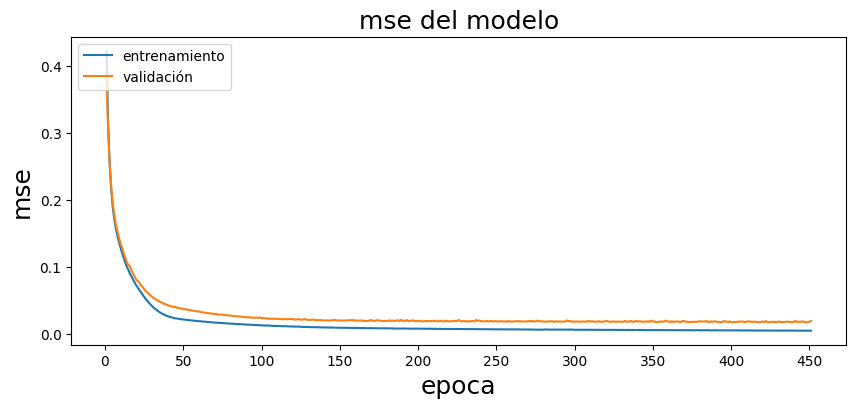


Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 0.01775

Epoch 1: val_loss did not improve from 

In [157]:
from IPython.display import clear_output

for e in range(epochs):
    history = model.fit(X_train, y_train,
                        batch_size=batchsize, epochs=1,
                        callbacks = [checkpoint], verbose = 0,
                        validation_data=(X_val, y_val))
    losses_train.append(history.history["loss"])
    losses_val.append(history.history["val_loss"])
    if (e%50)==0:
        clear_output()
        grafica_entrenamiento(losses_train, losses_val)

In [158]:
from keras.models import load_model

model = load_model(model_file)

In [109]:
y_train_prediction = model.predict(X_train, verbose=0).flatten()
R2_score(y_train, y_train_prediction)

0.5659696530698305

In [110]:
y_val_prediction = model.predict(X_val, verbose=0).flatten()
R2_score(y_val, y_val_prediction)

0.6016181374294868

In [111]:
fechas_val[0], fechas_val[-1]

(numpy.datetime64('2014-06-27T00:00:00.000000'),
 numpy.datetime64('2015-01-12T00:00:00.000000'))

In [112]:
y_test_prediction = model.predict(X_test, verbose=0).flatten()
R2_score(y_test, y_test_prediction)

0.5333141539457478

In [113]:
y_train_prediction[:5]

array([0.15788156, 0.9544553 , 0.94931763, 0.9456479 , 0.9333784 ],
      dtype=float32)

In [114]:
y_train[:5]

array([0.78  , 0.8016, 0.8088, 0.8254, 1.0364])

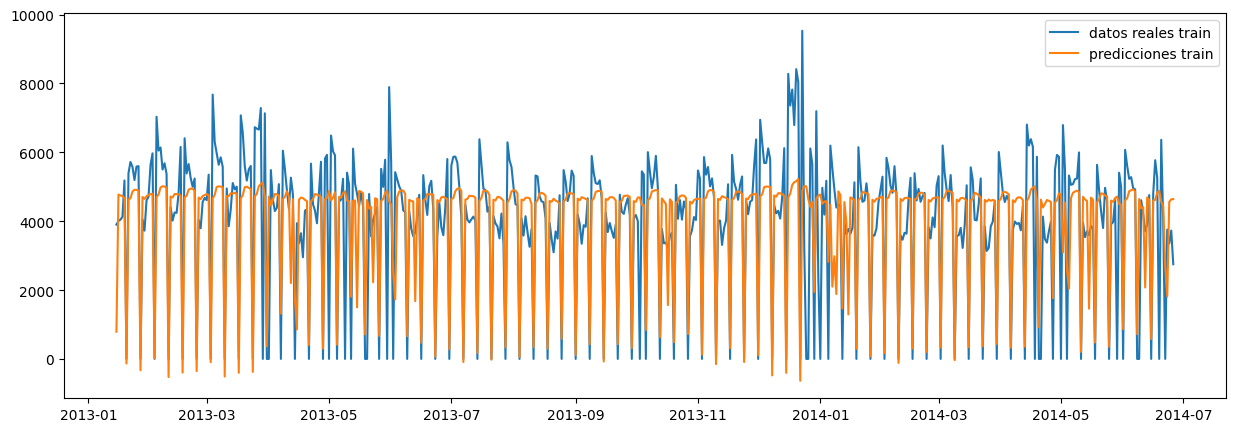

In [115]:
plt.figure(figsize=(15,5))
plt.plot(fechas_train, target_train, label="datos reales train")
plt.plot(fechas_train, inverse_transform(y_train_prediction), label="predicciones train")
plt.legend();

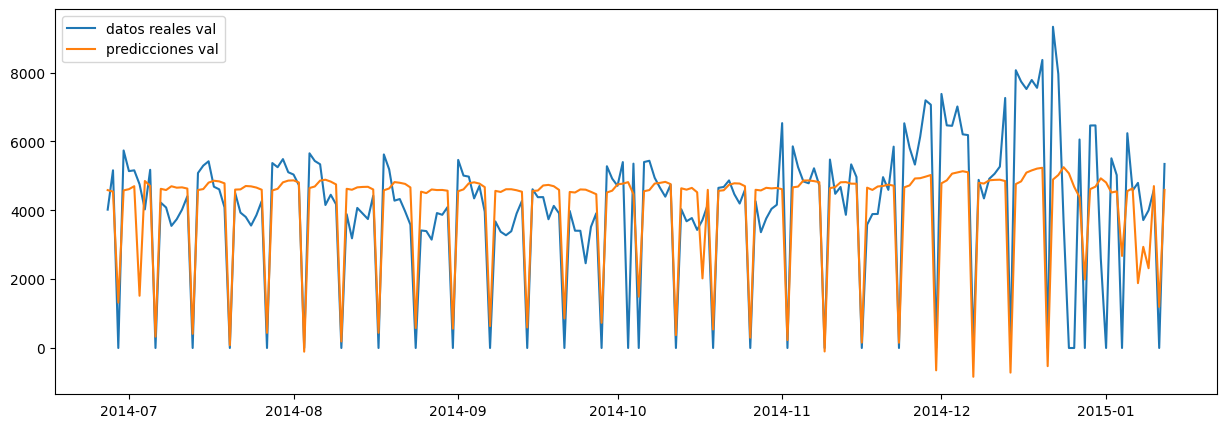

In [116]:
plt.figure(figsize=(15,5))
plt.plot(fechas_val, target_val, label="datos reales val")
plt.plot(fechas_val, inverse_transform(y_val_prediction), label="predicciones val")
plt.legend();

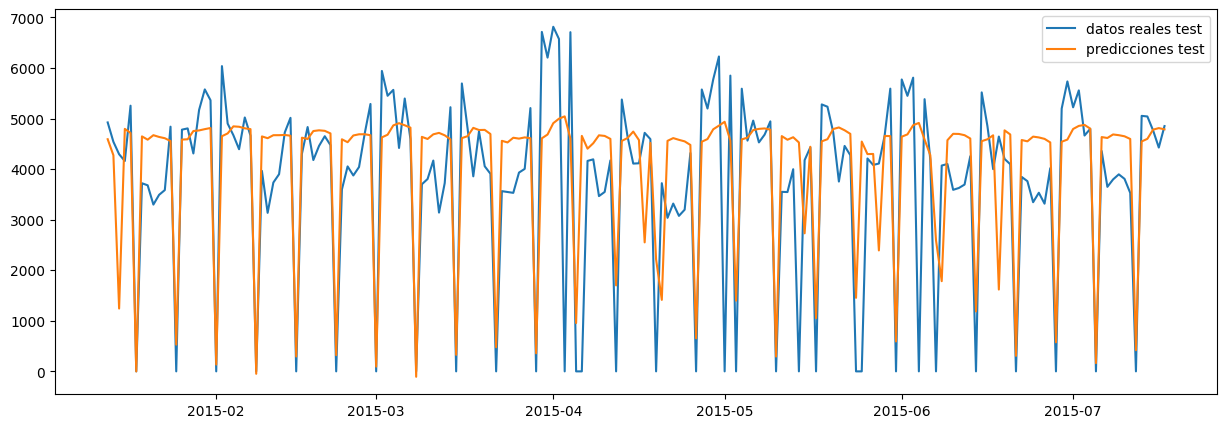

In [117]:
plt.figure(figsize=(15,5))
plt.plot(fechas_test, target_test, label="datos reales test")
plt.plot(fechas_test, inverse_transform(y_test_prediction), label="predicciones test")
plt.legend();

### Segundo modelo: utilizamos la variable endógena y exógenas

In [118]:
from my_utils_series_temporales import int2dummy

In [119]:
min(mes), max(mes)

(1, 12)

In [120]:
mes[:50]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2])

In [121]:
dummies_mes = int2dummy(mes, minimo=1, maximo=12)
dummies_mes[:50]

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.,

In [122]:
min(day_of_week), max(day_of_week)

(1, 7)

In [123]:
dummies_day_of_week = int2dummy(day_of_week, minimo=1, maximo=7)
dummies_day_of_week[:50]

array([[0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.],
 

In [126]:
# estas tres listas deben tener el mismo número de elementos:
series         = [target_transf, festivo, promo, open_]
se_saben_antes = [False, True, True, True]
                  
for i in range(12-1):
    series.append(dummies_mes[:,i])
    se_saben_antes.append(True)

for i in range(7-1):
    series.append(dummies_day_of_week[:,i])
    se_saben_antes.append(True)

In [127]:
W = 5

In [128]:
X, y = enventanar(series, target=0, se_saben_antes=se_saben_antes, W_in=W)

In [129]:
print(target_transf[:10])

[0.     1.106  0.8654 0.8972 0.9994 0.     1.4352 1.116  1.0942 0.9784]


In [130]:
target.shape

(928,)

In [131]:
X.shape, y.shape

((928, 5, 21), (928,))

In [132]:
X[:10]

array([[[   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan, 1.    , 0.    , ..., 0.    , 0.    , 0.    ]],

       [[   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan, 1.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [0.    , 1.    , 0.    , ..., 0.    , 0.    , 0.    ]],

       [[   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan,    nan,    nan, ...,    nan,    nan,    nan],
        [   nan, 1.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [0.    , 1.    , 0.    , ..., 0.    , 0.    , 0.    ],
        [1.106 , 1.    , 0.    , ..., 1.    , 0.    , 0.    ]],

       ...,

       [[0.8654, 1.    , 0.    , ...

In [133]:
y[:10]

array([0.    , 1.106 , 0.8654, 0.8972, 0.9994, 0.    , 1.4352, 1.116 ,
       1.0942, 0.9784])

In [134]:
fechas_str = [str(x) for x in fechas]

In [135]:
#info_enventanado(X[:10], y[:10], nombres_series=nombres_series, nombre_target="target transf",
#                 tiempos=fechas_str[:10])

In [136]:
train_percentage = 0.8
punto_corte = int(len(X)*train_percentage)
punto_corte

742

In [137]:
Nval = 200 # esos últimos días de training los uso para validar

X_test = X[punto_corte:]
y_test = y[punto_corte:]
fechas_test = fechas[punto_corte:]
target_test = target[punto_corte:]

X_aux = X[W:punto_corte]
y_aux = y[W:punto_corte]
fechas_aux = fechas[W:punto_corte]
target_aux = target[W:punto_corte]

X_train = X_aux[:-Nval]
y_train = y_aux[:-Nval]
fechas_train = fechas_aux[:-Nval]
target_train = target_aux[:-Nval]

X_val = X_aux[-Nval:]
y_val = y_aux[-Nval:]
fechas_val = fechas_aux[-Nval:]
target_val = target_aux[-Nval:]

In [138]:
X_train.shape, y_train.shape, fechas_train.shape, target_train.shape

((537, 5, 21), (537,), (537,), (537,))

In [139]:
X_val.shape, y_val.shape, fechas_val.shape, target_val.shape

((200, 5, 21), (200,), (200,), (200,))

In [140]:
X_test.shape, y_test.shape, fechas_test.shape, target_test.shape

((186, 5, 21), (186,), (186,), (186,))

In [141]:
X_train.shape[1:]

(5, 21)

In [159]:
model = Sequential()
model.add(GRU(10, input_shape=X_train.shape[1:]))
model.add(Dense(1, activation="relu"))
model.compile(loss="mean_squared_error", optimizer=RMSprop(1/1000)) # sensible a outliers PERO minimizar MSE = maximizar R2
#model.compile(loss="mean_absolute_error", optimizer=RMSprop(1/1000)) # menos sensible a outliers (menos sobreajusta), PERO ya no optimizo R2

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_1 (GRU)                 (None, 10)                990       
                                                                 
 dense_3 (Dense)             (None, 1)                 11        
                                                                 
Total params: 1001 (3.91 KB)
Trainable params: 1001 (3.91 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [160]:
epochs = 500
batchsize = 64

losses_train = []
losses_val = []
model_file = "bestmodel.keras"
checkpoint = ModelCheckpoint(model_file, monitor="val_loss", verbose=2, save_best_only=True)

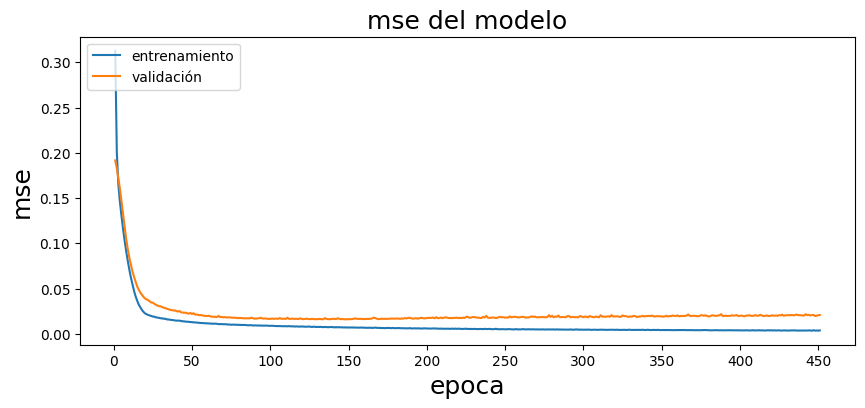


Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 0.01612

Epoch 1: val_loss did not improve from 

In [161]:
for e in range(epochs):
    history = model.fit(X_train, y_train,
                        batch_size=batchsize, epochs=1,
                        callbacks = [checkpoint], verbose = 0,
                        validation_data=(X_val, y_val))
    losses_train.append(history.history["loss"])
    losses_val.append(history.history["val_loss"])
    if (e%50)==0:
        clear_output()
        grafica_entrenamiento(losses_train, losses_val)

In [162]:
model = load_model(model_file)

In [163]:
y_train_prediction = model.predict(X_train, verbose=0).flatten()
R2_score(y_train, y_train_prediction)

0.9588055061223176

In [164]:
y_val_prediction = model.predict(X_val, verbose=0).flatten()
R2_score(y_val, y_val_prediction)

0.9077335672988132

In [165]:
fechas_val[0], fechas_val[-1]

(numpy.datetime64('2014-06-27T00:00:00.000000'),
 numpy.datetime64('2015-01-12T00:00:00.000000'))

In [166]:
y_test_prediction = model.predict(X_test, verbose=0).flatten()
R2_score(y_test, y_test_prediction)

0.9403678372784114

In [167]:
y_train_prediction[:5]

array([0.        , 1.3963052 , 1.0823416 , 1.031722  , 0.99366975],
      dtype=float32)

In [168]:
y_train[:5]

array([0.    , 1.4352, 1.116 , 1.0942, 0.9784])

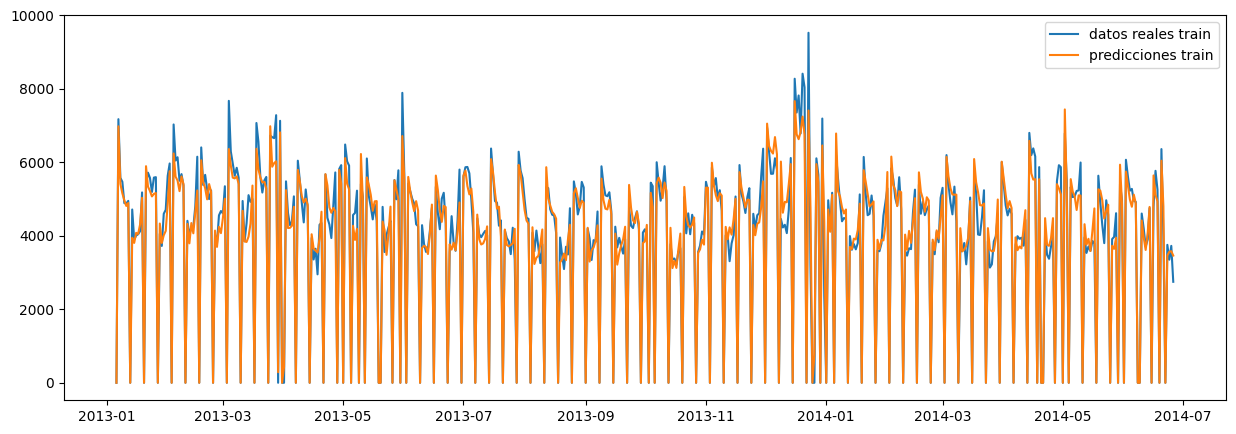

In [169]:
plt.figure(figsize=(15,5))
plt.plot(fechas_train, target_train, label="datos reales train")
plt.plot(fechas_train, inverse_transform(y_train_prediction), label="predicciones train")
plt.legend();

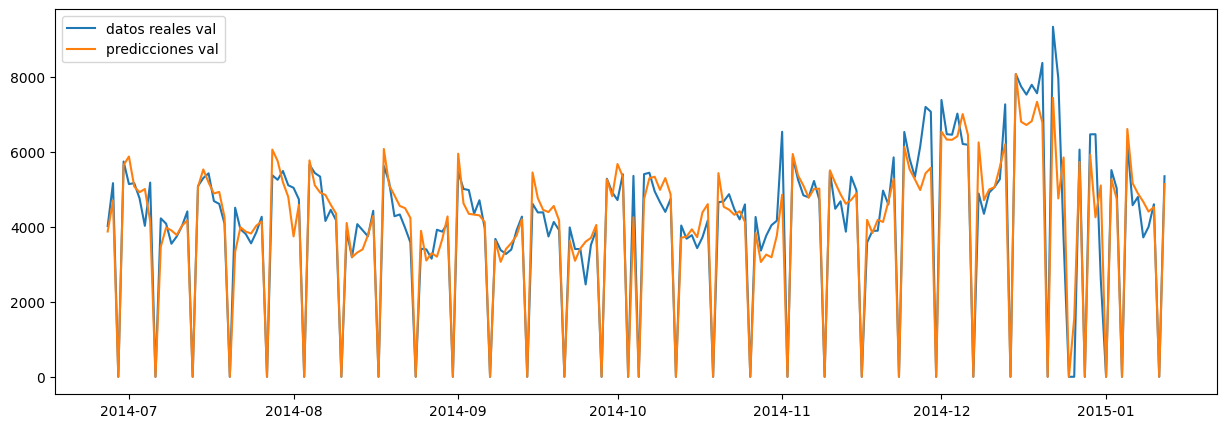

In [170]:
plt.figure(figsize=(15,5))
plt.plot(fechas_val, target_val, label="datos reales val")
plt.plot(fechas_val, inverse_transform(y_val_prediction), label="predicciones val")
plt.legend();

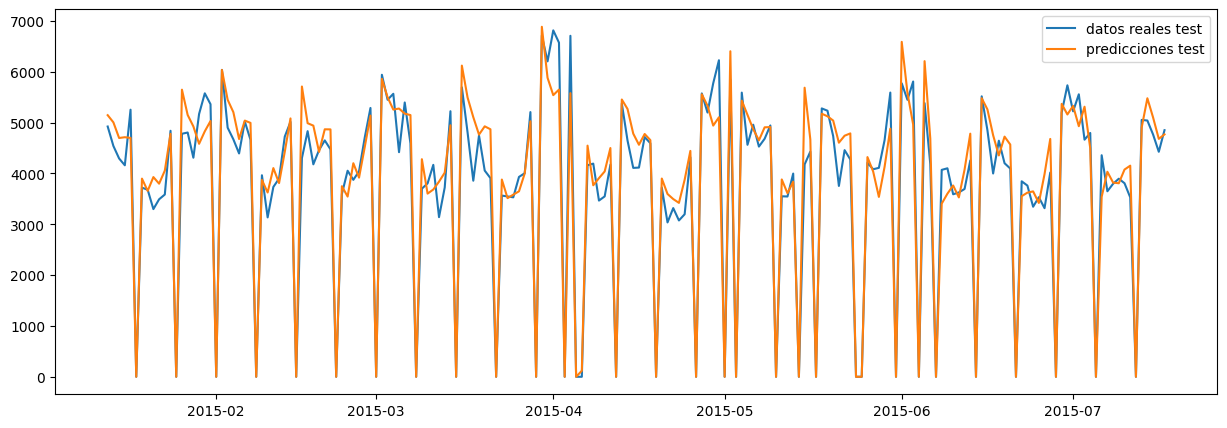

In [171]:
plt.figure(figsize=(15,5))
plt.plot(fechas_test, target_test, label="datos reales test")
plt.plot(fechas_test, inverse_transform(y_test_prediction), label="predicciones test")
plt.legend();

**Ejercicio:**

Optimizar la red ajustando estos hiperparámetros:

- W
- Número de neuronas en capa recurrente
- Tipo de capa recurrente (LSTM, GRU, RNN)
- Algoritmo de optimización (y su learning rate)
- Variables del modelo

### Predicción a varias días usando auto-regresión

In [172]:
X_test_con_nans = X_test.copy()

In [173]:
for i in range(len(X_test_con_nans)):
    X_test_con_nans[i,max(0,W-i):,0] = np.NaN

In [174]:
X_test_con_nans[:10,:,0]

array([[0.7432, 0.7996, 0.9198, 0.    , 1.0692],
       [0.7996, 0.9198, 0.    , 1.0692,    nan],
       [0.9198, 0.    , 1.0692,    nan,    nan],
       [0.    , 1.0692,    nan,    nan,    nan],
       [1.0692,    nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan],
       [   nan,    nan,    nan,    nan,    nan]])

In [175]:
X_test_con_nans[0].shape

(5, 21)

In [176]:
def predice_un_dia(modelo, ventana_entrada, ventana_salida_v0):
    # ventana_salida_v0: ventana siguiente a la ventana de entrada, pero con la variable endógena sin rellenar
    # en el nuevo día
    prediccion = modelo.predict(np.array( [ventana_entrada] ), verbose=0)[0][0]
    ventana_salida = ventana_salida_v0.copy()
    ventana_salida[:-1,0] = ventana_entrada[1:,0].copy()
    ventana_salida[-1,0] = prediccion
    
    return prediccion, ventana_salida

In [177]:
predice_un_dia(model,
               ventana_entrada=X_test_con_nans[0],
               ventana_salida_v0=X_test_con_nans[1])

(1.029398,
 array([[0.7996    , 0.        , 0.        , 1.        , 1.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         1.        ],
        [0.9198    , 0.        , 0.        , 0.        , 1.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 1.        , 1.        , 1.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         1.        , 0.        , 0.        , 0.        , 0.        ,
         0.        ],
        [1.0692    , 0.        , 1.        , 1.        , 1.        ,
         0.        , 0.   

In [178]:
y_test_prediction[0]

1.029398

In [179]:
X_test_con_nans[1]

array([[0.7996, 0.    , 0.    , 1.    , 1.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 1.    ],
       [0.9198, 0.    , 0.    , 0.    , 1.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 1.    , 1.    , 1.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 1.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [1.0692, 0.    , 1.    , 1.    , 1.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        1.    , 0.    , 0.    , 0.    , 0.    ],
       [   nan, 0.    , 1.    , 1.    , 1.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 1.    , 0.    , 0.    , 0.    ]])

In [180]:
y_test_prediction_AR = []

ventana_entrada     = X_test_con_nans[0]
ventana_entrada_sig = X_test_con_nans[1]

for i in range(len(X_test_con_nans)):
    
    if (i+1)<len(X_test_con_nans):
        ventana_entrada_sig = X_test_con_nans[i+1]
    prediccion, nueva_ventana_entrada = predice_un_dia(model,
                                                       ventana_entrada, # no debería haber nans
                                                       ventana_entrada_sig)
    y_test_prediction_AR.append(prediccion)
    ventana_entrada = nueva_ventana_entrada

In [181]:
y_test_prediction_AR = np.array(y_test_prediction_AR)

In [182]:
y_test_prediction_AR

array([1.029398  , 1.0119206 , 0.9722676 , 0.9876045 , 0.99072105,
       0.        , 0.8041032 , 0.74601656, 0.7954245 , 0.79512405,
       0.8499453 , 1.003614  , 0.        , 1.1736104 , 1.0872712 ,
       1.0385761 , 0.9950012 , 1.0082068 , 1.0035535 , 0.        ,
       1.1809279 , 1.0751221 , 1.0523576 , 0.96884346, 1.0491753 ,
       1.0288725 , 0.        , 0.81959844, 0.7400953 , 0.84802794,
       0.8001857 , 0.9143901 , 1.0277088 , 0.        , 1.150969  ,
       1.0525272 , 1.0341885 , 0.9605364 , 1.0412143 , 1.0238602 ,
       0.        , 0.81543374, 0.73857844, 0.8468984 , 0.7993573 ,
       0.91378665, 1.0272245 , 0.        , 1.1651345 , 1.0928167 ,
       1.0492687 , 1.0376931 , 1.0547941 , 1.0381685 , 0.        ,
       0.88934463, 0.7486825 , 0.75009054, 0.7603225 , 0.813084  ,
       1.0113348 , 0.        , 1.2310394 , 1.1193444 , 1.0629436 ,
       1.047497  , 1.0640095 , 1.043202  , 0.        , 0.89313567,
       0.7498287 , 0.7509169 , 0.7609655 , 0.81352276, 1.01162

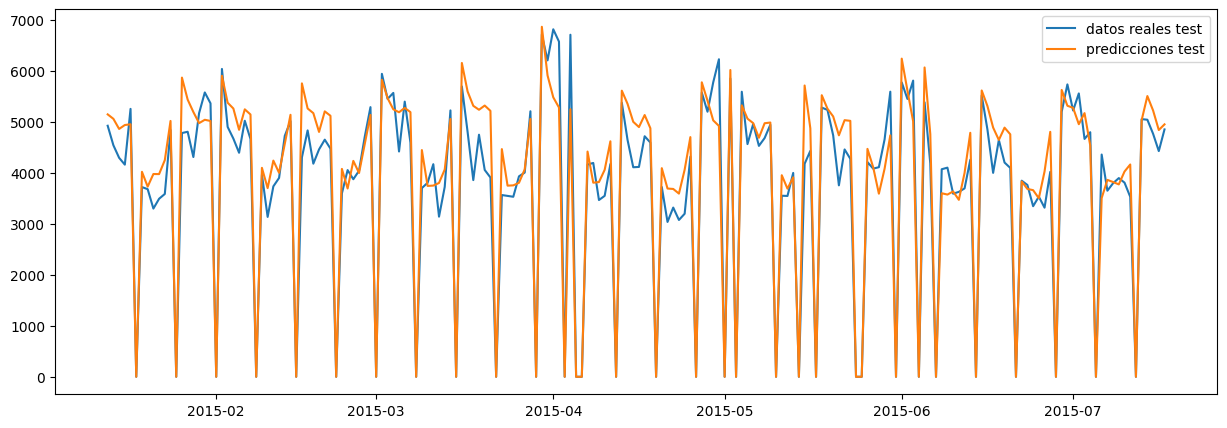

In [183]:
plt.figure(figsize=(15,5))
plt.plot(fechas_test, target_test, label="datos reales test")
plt.plot(fechas_test, inverse_transform(y_test_prediction_AR), label="predicciones test")
plt.legend();

In [184]:
# predicciones a 1 día (usando siempre como ventana de entrada datos reales)
y_test_prediction[:20]

array([1.029398  , 1.0011114 , 0.9396214 , 0.94272155, 0.9399266 ,
       0.        , 0.77982134, 0.73146164, 0.78584594, 0.7598706 ,
       0.8111686 , 0.95580536, 0.        , 1.1297282 , 1.0303171 ,
       0.9851491 , 0.91678953, 0.9659251 , 1.0064597 , 0.        ],
      dtype=float32)

In [185]:
# predicciones a varios días (usando como ventana de entrada predicciones)
y_test_prediction_AR[:20]

array([1.029398  , 1.0119206 , 0.9722676 , 0.9876045 , 0.99072105,
       0.        , 0.8041032 , 0.74601656, 0.7954245 , 0.79512405,
       0.8499453 , 1.003614  , 0.        , 1.1736104 , 1.0872712 ,
       1.0385761 , 0.9950012 , 1.0082068 , 1.0035535 , 0.        ],
      dtype=float32)